In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
batches = [f"FA{str(i).zfill(3)}" for i in range(1, 12)]
batches

['FA001',
 'FA002',
 'FA003',
 'FA004',
 'FA005',
 'FA006',
 'FA007',
 'FA008',
 'FA009',
 'FA010',
 'FA011']

In [3]:
nstep = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", header = 1)
nstep = nstep[2:].reset_index(drop = True)
nstep.columns = ["Batch"] + nstep.columns.tolist()[1:]

nstep_ts = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", sheet_name = 1, header = 1)
nstep_ts.insert(0, "Batch", nstep_ts["Run"].apply(lambda x: x.split("_")[0]))

nstep_ts_start = nstep_ts[["Batch", "Process Time [h]"]].groupby("Batch").min().reset_index()
nstep_ts_start.columns = ["Batch", "Process Start Time"]

nstep_ts = pd.merge(nstep_ts_start, nstep_ts, on = "Batch")
nstep_ts["Process Time [h]"] -= nstep_ts["Process Start Time"]
nstep_ts.insert(3, "Process Day", nstep_ts["Process Time [h]"].apply(lambda x: math.ceil((x - 12)/24)))
nstep_ts.drop("Process Start Time", axis = 1, inplace = True)

In [4]:
target = nstep[["Batch", "STR2K_D14_4_1_PA_HPLC_Concentration"]]
target.columns = ["Batch", "D14 Titer"]
target

,Batch,D14 Titer
0,FA001,5.19
1,FA002,4.86
2,FA003,4.63
3,FA004,4.62
4,FA005,3.91
5,FA006,5.63
6,FA007,5.79
7,FA008,5.89
8,FA009,4.84
9,FA010,5.56


In [6]:
hyclone_a_sub = hyclone_a[hyclone_a.columns[1:4]].copy()
hyclone_a_sub.columns = ["HYCLONE A " + col for col in hyclone_a_sub.columns]
hyclone_a_sub = pd.merge(hyclone_a[["CAMPAIGN"]], hyclone_a_sub, left_index = True, right_index = True)
hyclone_a_sub

,CAMPAIGN,HYCLONE A Osmolality,HYCLONE A Preparation Time,HYCLONE A pH
0,FA001,279,356,6.68
1,FA002,303,327,6.68
2,FA003,275,336,6.72
3,FA004,279,238,6.73
4,FA005,274,286,6.71
5,FA006,278,261,6.62
6,FA007,299,328,6.66
7,FA008,294,245,6.68
8,FA009,266,272,6.78
9,FA010,270,346,6.77


In [7]:
hyclone_b_sub = hyclone_b[hyclone_b.columns[1:4]].copy()
hyclone_b_sub.columns = ["HYCLONE B " + col for col in hyclone_b_sub.columns]
hyclone_b_sub = pd.merge(hyclone_b[["CAMPAIGN"]], hyclone_b_sub, left_index = True, right_index = True)
hyclone_b_sub

,CAMPAIGN,HYCLONE B Osmolality,HYCLONE B Preparation Time,HYCLONE B pH
0,FA001,227,332,11.01
1,FA002,229,409,11.11
2,FA003,229,292,11.07
3,FA004,220,319,11.13
4,FA005,230,309,11.1
5,FA006,230,276,11.07
6,FA007,229,303,11.04
7,FA008,226,314,11.17
8,FA009,232,356,11.09
9,FA010,227,250,11.06


In [8]:
opticho_n1 = opticho[opticho["step"].apply(lambda x: "N-1" in x)].copy().reset_index(drop = True)
opticho_n1 = opticho_n1[["CAMPAIGN"] + opticho_n1.columns[1:4].tolist()]
opticho_n1.columns = ["CAMPAIGN"] + ["OPTICHO N-1 " + col for col in opticho_n1.columns[1:]]
opticho_n1

,CAMPAIGN,OPTICHO N-1 Osmolality,OPTICHO N-1 Preparation Time,OPTICHO N-1 pH
0,FA001,275,270,7.09
1,FA002,276,207,7.03
2,FA003,276,120,7.11
3,FA004,277,140,7.09
4,FA005,278,161,7.09
5,FA006,278,200,7.01
6,FA007,276,202,7.06
7,FA008,277,262,7.04
8,FA009,280,262,7.04
9,FA010,274,247,7.11


In [9]:
opticho_n = opticho[opticho["step"].apply(lambda x: ("N " in x) | (x == "N"))].copy().reset_index(drop = True)
opticho_n = opticho_n[["CAMPAIGN"] + opticho_n.columns[1:4].tolist()]
opticho_n.columns = ["CAMPAIGN"] + ["OPTICHO N " + col for col in opticho_n.columns[1:]]
opticho_n

,CAMPAIGN,OPTICHO N Osmolality,OPTICHO N Preparation Time,OPTICHO N pH
0,FA001,276,177,6.93
1,FA002,277,136,7.07
2,FA003,276,116,7.03
3,FA004,277,174,7.04
4,FA005,277,167,7
5,FA006,278,200,7.01
6,FA007,276,202,7.06
7,FA008,277,262,7.04
8,FA009,280,262,7.04
9,FA010,274,247,7.11


In [10]:
merged = pd.merge(hyclone_a_sub, hyclone_b_sub, on = "CAMPAIGN")
merged = pd.merge(merged, opticho_n, on = "CAMPAIGN")
merged = pd.merge(merged, opticho_n1, on = "CAMPAIGN")
merged[merged.columns[1:]] = merged[merged.columns[1:]].astype(float)
merged

,CAMPAIGN,HYCLONE A Osmolality,HYCLONE A Preparation Time,HYCLONE A pH,HYCLONE B Osmolality,HYCLONE B Preparation Time,HYCLONE B pH,OPTICHO N Osmolality,OPTICHO N Preparation Time,OPTICHO N pH,OPTICHO N-1 Osmolality,OPTICHO N-1 Preparation Time,OPTICHO N-1 pH
0,FA001,279.0,356.0,6.68,227.0,332.0,11.01,276.0,177.0,6.93,275.0,270.0,7.09
1,FA002,303.0,327.0,6.68,229.0,409.0,11.11,277.0,136.0,7.07,276.0,207.0,7.03
2,FA003,275.0,336.0,6.72,229.0,292.0,11.07,276.0,116.0,7.03,276.0,120.0,7.11
3,FA004,279.0,238.0,6.73,220.0,319.0,11.13,277.0,174.0,7.04,277.0,140.0,7.09
4,FA005,274.0,286.0,6.71,230.0,309.0,11.10,277.0,167.0,7.00,278.0,161.0,7.09
5,FA006,278.0,261.0,6.62,230.0,276.0,11.07,278.0,200.0,7.01,278.0,200.0,7.01
6,FA007,299.0,328.0,6.66,229.0,303.0,11.04,276.0,202.0,7.06,276.0,202.0,7.06
7,FA008,294.0,245.0,6.68,226.0,314.0,11.17,277.0,262.0,7.04,277.0,262.0,7.04
8,FA009,266.0,272.0,6.78,232.0,356.0,11.09,280.0,262.0,7.04,280.0,262.0,7.04
9,FA010,270.0,346.0,6.77,227.0,250.0,11.06,274.0,247.0,7.11,274.0,247.0,7.11


In [11]:
target

,Batch,D14 Titer
0,FA001,5.19
1,FA002,4.86
2,FA003,4.63
3,FA004,4.62
4,FA005,3.91
5,FA006,5.63
6,FA007,5.79
7,FA008,5.89
8,FA009,4.84
9,FA010,5.56


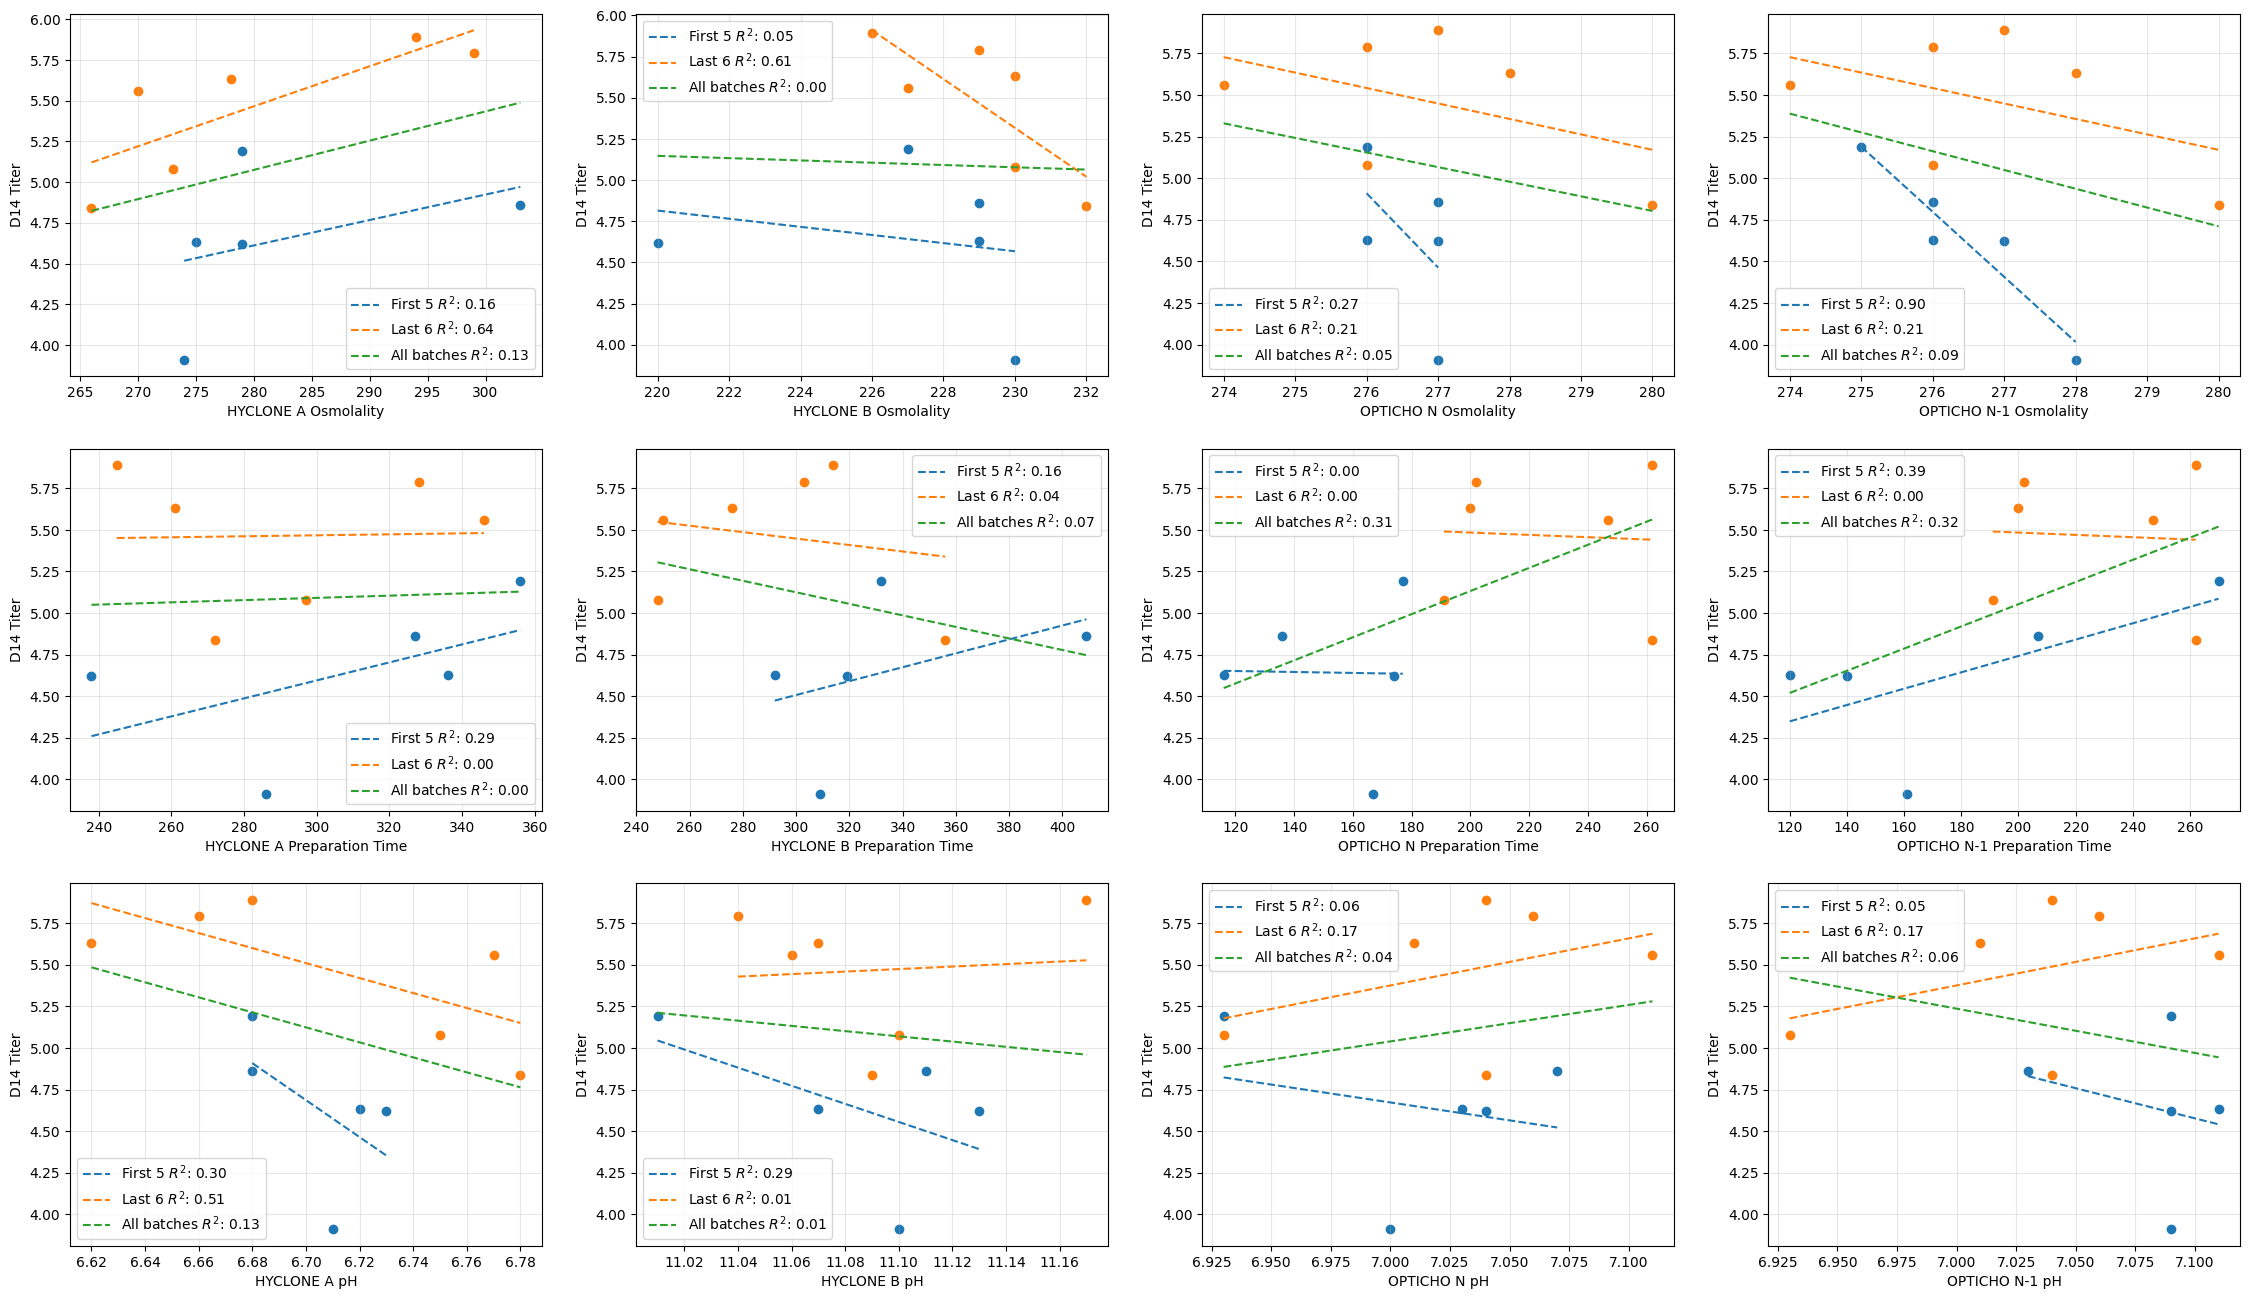

In [18]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def fit_summary(X, y):
    """
    Fit a linear regression model and return:
      - min X
      - predicted y at min X
      - max X
      - predicted y at max X
      - R² score
    """
    
    X = np.asarray(X).reshape(-1, 1)
    y = np.asarray(y)

    # Fit model
    model = LinearRegression()
    model.fit(X, y)

    # Min and max X values
    x_min = float(X.min())
    x_max = float(X.max())

    # Predicted y values at min/max X
    y_min_fit = float(model.predict([[x_min]])[0])
    y_max_fit = float(model.predict([[x_max]])[0])

    # R²
    y_pred = model.predict(X)
    r2 = float(r2_score(y, y_pred))

    return {
        "x_min": x_min,
        "y_fit_at_x_min": y_min_fit,
        "x_max": x_max,
        "y_fit_at_x_max": y_max_fit,
        "r2": r2,
        "slope": float(model.coef_[0]),
        "intercept": float(model.intercept_)
    }

fig, axs = plt.subplots(3, 4, figsize = (28, 16))

for feat_idx, feat in enumerate(merged.columns[1:]):
    row_idx = feat_idx // 3
    col_idx = feat_idx % 3

    ax = axs[col_idx][row_idx]
    X = merged[feat].tolist()
    y = target["D14 Titer"].tolist()

    ax.scatter(X[:5], y[:5])
    summary = fit_summary(X[:5], y[:5])
    ax.plot([summary['x_min'], summary['x_max']], [summary['y_fit_at_x_min'], summary['y_fit_at_x_max']], label = f"First 5 $R^2$: {summary['r2']:.2f}", linestyle = '--')
    ax.scatter(X[5:], y[5:])
    summary = fit_summary(X[5:], y[5:])
    ax.plot([summary['x_min'], summary['x_max']], [summary['y_fit_at_x_min'], summary['y_fit_at_x_max']], label = f"Last 6 $R^2$: {summary['r2']:.2f}", linestyle = '--')
    summary = fit_summary(X, y)
    ax.plot([summary['x_min'], summary['x_max']], [summary['y_fit_at_x_min'], summary['y_fit_at_x_max']], label = f"All batches $R^2$: {summary['r2']:.2f}", linestyle = '--')
    ax.set_xlabel(feat)
    ax.set_ylabel("D14 Titer")
    ax.legend()
    ax.grid(alpha = 0.3)